In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import anndata as ad

In [ ]:
control_1_file_loc = r"C:\Users\mikep\Data\Cellranger_output\control\rep1"
control_2_file_loc = r"C:\Users\mikep\Data\Cellranger_output\control\rep2"
control_3_file_loc = r"C:\Users\mikep\Data\Cellranger_output\control\rep3"
control_1a_file_loc = r"C:\Users\mikep\Data\Cellranger_output\control\rep1a"

In [ ]:
drought_1_file_loc = r"C:\Users\mikep\Data\Cellranger_output\drought\rep1"
drought_2_file_loc = r"C:\Users\mikep\Data\Cellranger_output\drought\rep2"
drought_3_file_loc = r"C:\Users\mikep\Data\Cellranger_output\drought\rep3"

heat_1_file_loc = r"C:\Users\mikep\Data\Cellranger_output\heat\rep1"
heat_2_file_loc = r"C:\Users\mikep\Data\Cellranger_output\heat\rep2"
heat_3_file_loc = r"C:\Users\mikep\Data\Cellranger_output\heat\rep3"

HD_1_file_loc = r"C:\Users\mikep\Data\Cellranger_output\HD\rep1"
HD_2_file_loc = r"C:\Users\mikep\Data\Cellranger_output\HD\rep2"
HD_3_file_loc = r"C:\Users\mikep\Data\Cellranger_output\HD\rep3"

In [ ]:
control_1 = sc.read_10x_mtx(
    control_1_file_loc,
    var_names="gene_symbols",
)
control_2 = sc.read_10x_mtx(
    control_2_file_loc,
    var_names="gene_symbols",
)
control_3 = sc.read_10x_mtx(
    control_3_file_loc,
    var_names="gene_symbols",
)
control_1a = sc.read_10x_mtx(
    control_1a_file_loc,
    var_names="gene_symbols",
)
heat_1 = sc.read_10x_mtx(
    heat_1_file_loc,
    var_names="gene_symbols",
)
heat_2 = sc.read_10x_mtx(
    heat_2_file_loc,
    var_names="gene_symbols",
)
heat_3 = sc.read_10x_mtx(
    heat_3_file_loc,
    var_names="gene_symbols",
)
drought_1 = sc.read_10x_mtx(
    drought_1_file_loc,
    var_names="gene_symbols",
)
drought_2 = sc.read_10x_mtx(
    drought_2_file_loc,
    var_names="gene_symbols",
)
drought_3 = sc.read_10x_mtx(
    drought_3_file_loc,
    var_names="gene_symbols",
)
HD_1 = sc.read_10x_mtx(
    HD_1_file_loc,
    var_names="gene_symbols",
)
HD_2 = sc.read_10x_mtx(
    HD_2_file_loc,
    var_names="gene_symbols",
)
HD_3 = sc.read_10x_mtx(
    HD_3_file_loc,
    var_names="gene_symbols",
)

In [ ]:
full_concatenated_adata = ad.concat(
    [
        control_1,
        control_2,
        control_3,
        control_1a,
        heat_1,
        heat_2,
        heat_3,
        drought_1,
        drought_2,
        drought_3,
        HD_1,
        HD_2,
        HD_3,
    ],
    join="outer",
    label="batch",
    keys=[
        "control_1",
        "control_2",
        "control_3",
        "control_1a",
        "heat_1",
        "heat_2",
        "heat_3",
        "drought_1",
        "drought_2",
        "drought_3",
        "HD_1",
        "HD_2",
        "HD_3",
    ],
    index_unique="-",
)

In [ ]:
sc.pp.calculate_qc_metrics(
    full_concatenated_adata,
    inplace=True,
)

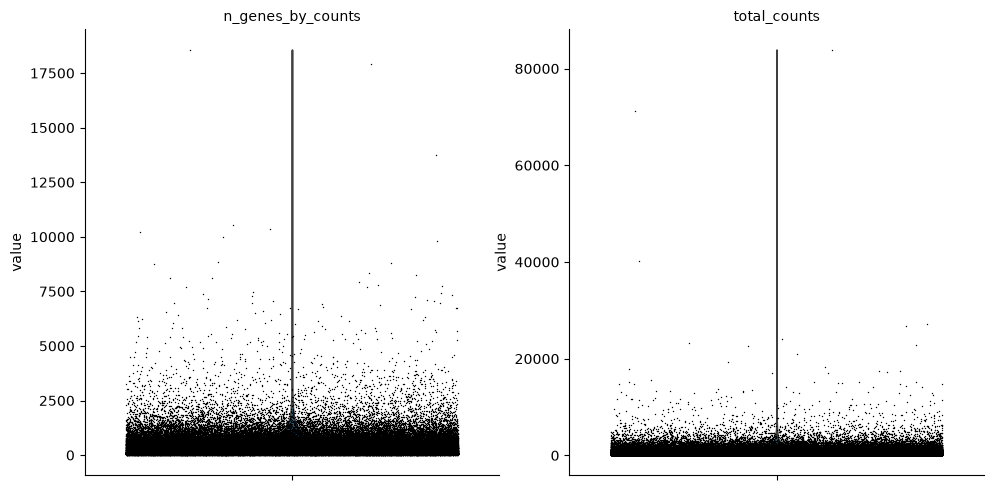

In [ ]:
sc.pl.violin(
    full_concatenated_adata,
    [
        "n_genes_by_counts",
        "total_counts",
    ],
    jitter=0.4,
    multi_panel=True,
)

In [ ]:
sc.pp.filter_cells(
    full_concatenated_adata,
    min_genes=500,
)
sc.pp.filter_genes(full_concatenated_adata, min_cells=5)

In [ ]:
full_concatenated_adata

AnnData object with n_obs × n_vars = 30139 × 40380
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    layers: None (.X)

In [ ]:
sc.pp.normalize_total(full_concatenated_adata, target_sum=1e4)
sc.pp.log1p(full_concatenated_adata)

In [ ]:
full_concatenated_adata

AnnData object with n_obs × n_vars = 30139 × 40380
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p'
    layers: None (.X)

In [ ]:
sc.pp.highly_variable_genes(
    full_concatenated_adata, n_top_genes=2000, batch_key="batch"
)

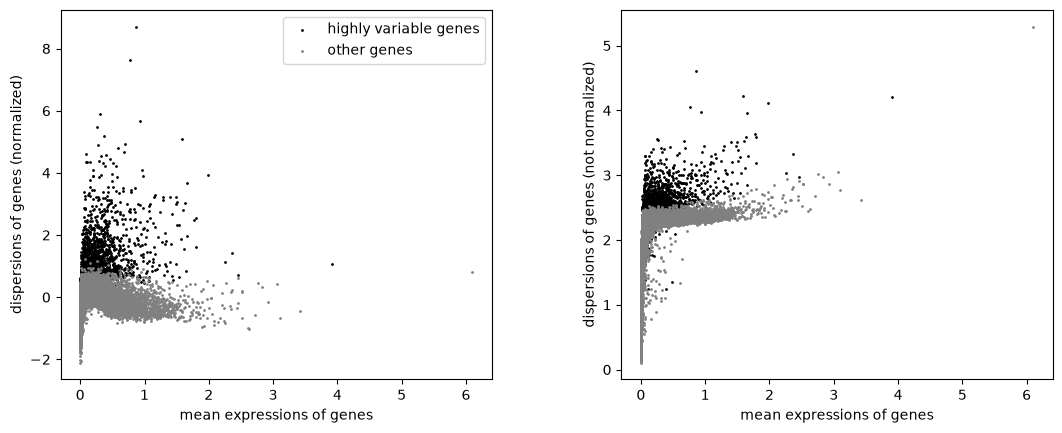

In [ ]:
sc.pl.highly_variable_genes(full_concatenated_adata)

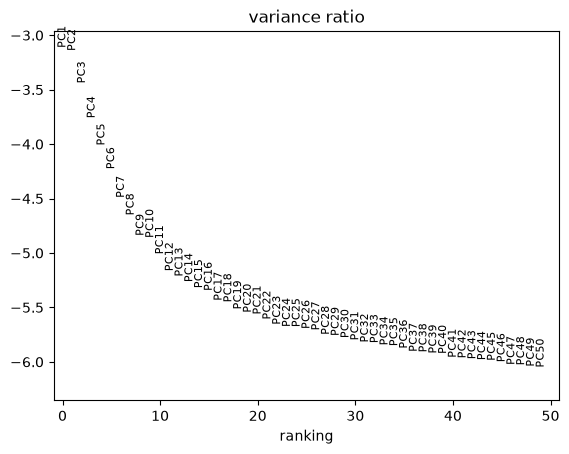

In [ ]:
sc.tl.pca(full_concatenated_adata)
sc.pl.pca_variance_ratio(full_concatenated_adata, n_pcs=50, log=True)

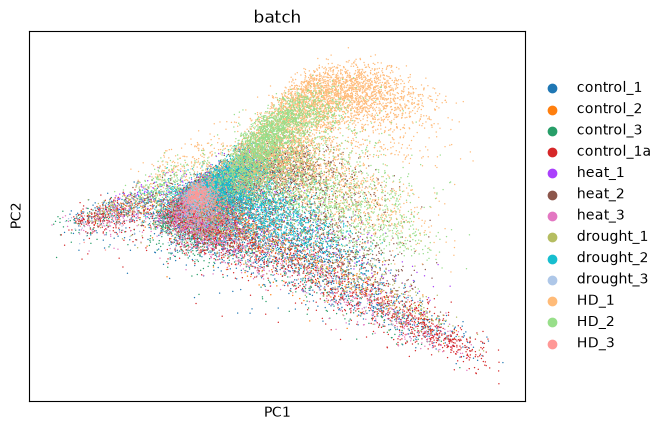

In [ ]:
sc.pl.pca(
    full_concatenated_adata,
    color=["batch"],
)

## Harmony integration

Run on the PCA, before the neighbour graph, so the UMAP, the leiden clustering and the two
cluster-based DE analyses below all use the integrated embedding.

Batch key is `replicate`, not `batch`: each library is a single treatment, so library is
nested inside treatment and correcting on it would remove the treatment effect along with the
batch. `replicate` is crossed with treatment - every block holds all four conditions.

Harmony only moves an embedding, so DE analysis 1 (library pseudobulk on raw counts) is
unchanged from the unintegrated notebook; analyses 2 and 3 use clusterings that do change.

In [ ]:
import harmonypy

# rep1/rep2/rep3, with control_1a folded into rep1 as in the DE section below
full_concatenated_adata.obs["replicate"] = (
    full_concatenated_adata.obs["batch"]
    .astype(str)
    .str.rsplit("_", n=1)
    .str[1]
    .replace({"1a": "1"})
    .radd("rep")
    .astype("category")
)

HARMONY_BATCH_KEY = "replicate"
EMBEDDING = "X_pca_harmony"

harmony_out = harmonypy.run_harmony(
    full_concatenated_adata.obsm["X_pca"],
    full_concatenated_adata.obs,
    [HARMONY_BATCH_KEY],
)

# harmonypy >= 0.2 returns Z_corr as (cells x PCs); older versions transpose it
Z = harmony_out.Z_corr
Z = Z.cpu().numpy() if hasattr(Z, "cpu") else np.asarray(Z)
if Z.shape[0] != full_concatenated_adata.n_obs:
    Z = Z.T
full_concatenated_adata.obsm[EMBEDDING] = np.ascontiguousarray(Z, dtype=np.float32)

print(full_concatenated_adata.obs["replicate"].value_counts().to_string())
print(full_concatenated_adata.obsm[EMBEDDING].shape)

2026-08-14 01:20:29,463 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2026-08-14 01:20:35,977 - harmonypy - INFO - sklearn.KMeans initialization complete.


2026-08-14 01:20:36,119 - harmonypy - INFO - Iteration 1 of 10


2026-08-14 01:20:44,812 - harmonypy - INFO - Iteration 2 of 10


2026-08-14 01:20:53,340 - harmonypy - INFO - Converged after 2 iterations


replicate
rep1    14635
rep2    10299
rep3     5205
(30139, 50)


In [ ]:
sc.pp.neighbors(full_concatenated_adata, use_rep=EMBEDDING)

In [ ]:
sc.tl.umap(full_concatenated_adata)

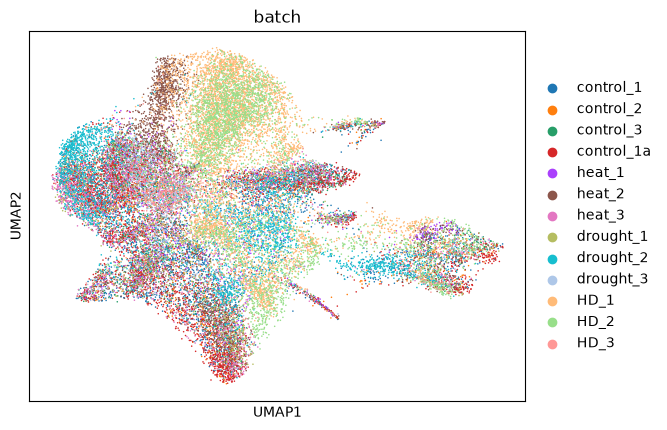

In [ ]:
sc.pl.umap(
    full_concatenated_adata,
    color="batch",
    size=5,
)

In [ ]:
sc.tl.leiden(full_concatenated_adata, flavor="igraph", resolution=0.8)

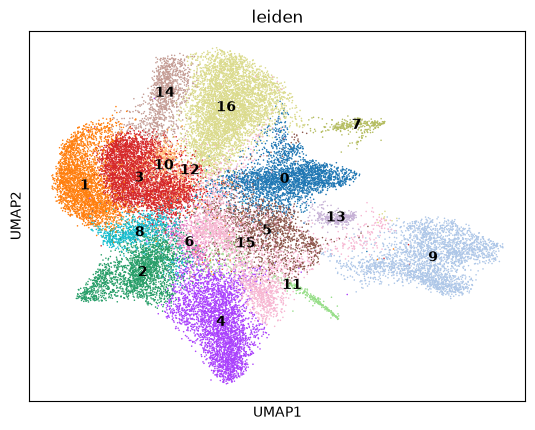

In [ ]:
sc.pl.umap(
    full_concatenated_adata,
    color=["leiden"],
    legend_loc="on data",
    size=5,
    legend_fontsize=10,
)

In [ ]:
labeled_data = sc.read_h5ad(
    "C:\\Users\\mikep\\git\\Soybean_Single_Cell_drought_heat\\Data\\anndata_export\\adata_rna.h5ad"
)
labeled_data

AnnData object with n_obs × n_vars = 30467 × 36042
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'pctCP', 'pctMT', 'nUMI_raw', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.3', 'SCT_snn_res.0.4', 'SCT_snn_res.0.5', 'SCT_snn_res.0.6', 'SCT_snn_res.0.7', 'SCT_snn_res.0.8', 'SCT_snn_res.0.9', 'SCT_snn_res.1', 'seurat_clusters', 'treatment', 'libraries', 'replicate', 'source_rds', 'integrated_snn_res.0.5', 'celltype_call', 'cluster_annot'
    var: 'highly_variable', 'in_integrated'
    uns: 'neighbors', 'pca', 'pca_loadings', 'source'
    obsm: 'X_pca', 'X_umap'
    obsp: 'connectivities', 'distances'
    layers: 'counts', None (.X)

In [ ]:
labeled_data.obs["cluster_annot"]

leaf_control_rep1_AATCCCTGTGATGGCT-1                      Epidermal-4
leaf_control_rep1_TTTACGCGTGGAAACG-1    Vascular/Phloem parenchyma-11
leaf_control_rep1_GAACACAAGTTACCGG-1                   Guard cells-12
leaf_control_rep1_TCATTGCGTGAGCAAG-1                 Bundle sheath-10
leaf_control_rep1_CTCATTAGTTAAGCCA-1                      Mesophyll-2
                                                    ...              
leaf_Heat_rep3_CAGGATGCATGTCGCG-1                         Mesophyll-8
leaf_Heat_rep3_CCTATAGCATGTCGCG-1                         Mesophyll-0
leaf_Heat_rep3_AGGTCCGGTGTCACGG-1                         Mesophyll-0
leaf_Heat_rep3_TTCATTCAGCTAATTG-1                      Guard cells-12
leaf_Heat_rep3_ATGATGGAGCAGGTGG-1                         Mesophyll-0
Name: cluster_annot, Length: 30467, dtype: category
Categories (17, str): ['Epidermal-4', 'Epidermal/Pavement-9', 'Guard cells-12', 'Hydathode cells-15', ..., 'Bundle sheath-3', 'Vascular/Phloem parenchyma-11', 'Companion cells-6'

28304 cells shared (30139 reclustered, 30467 annotated)


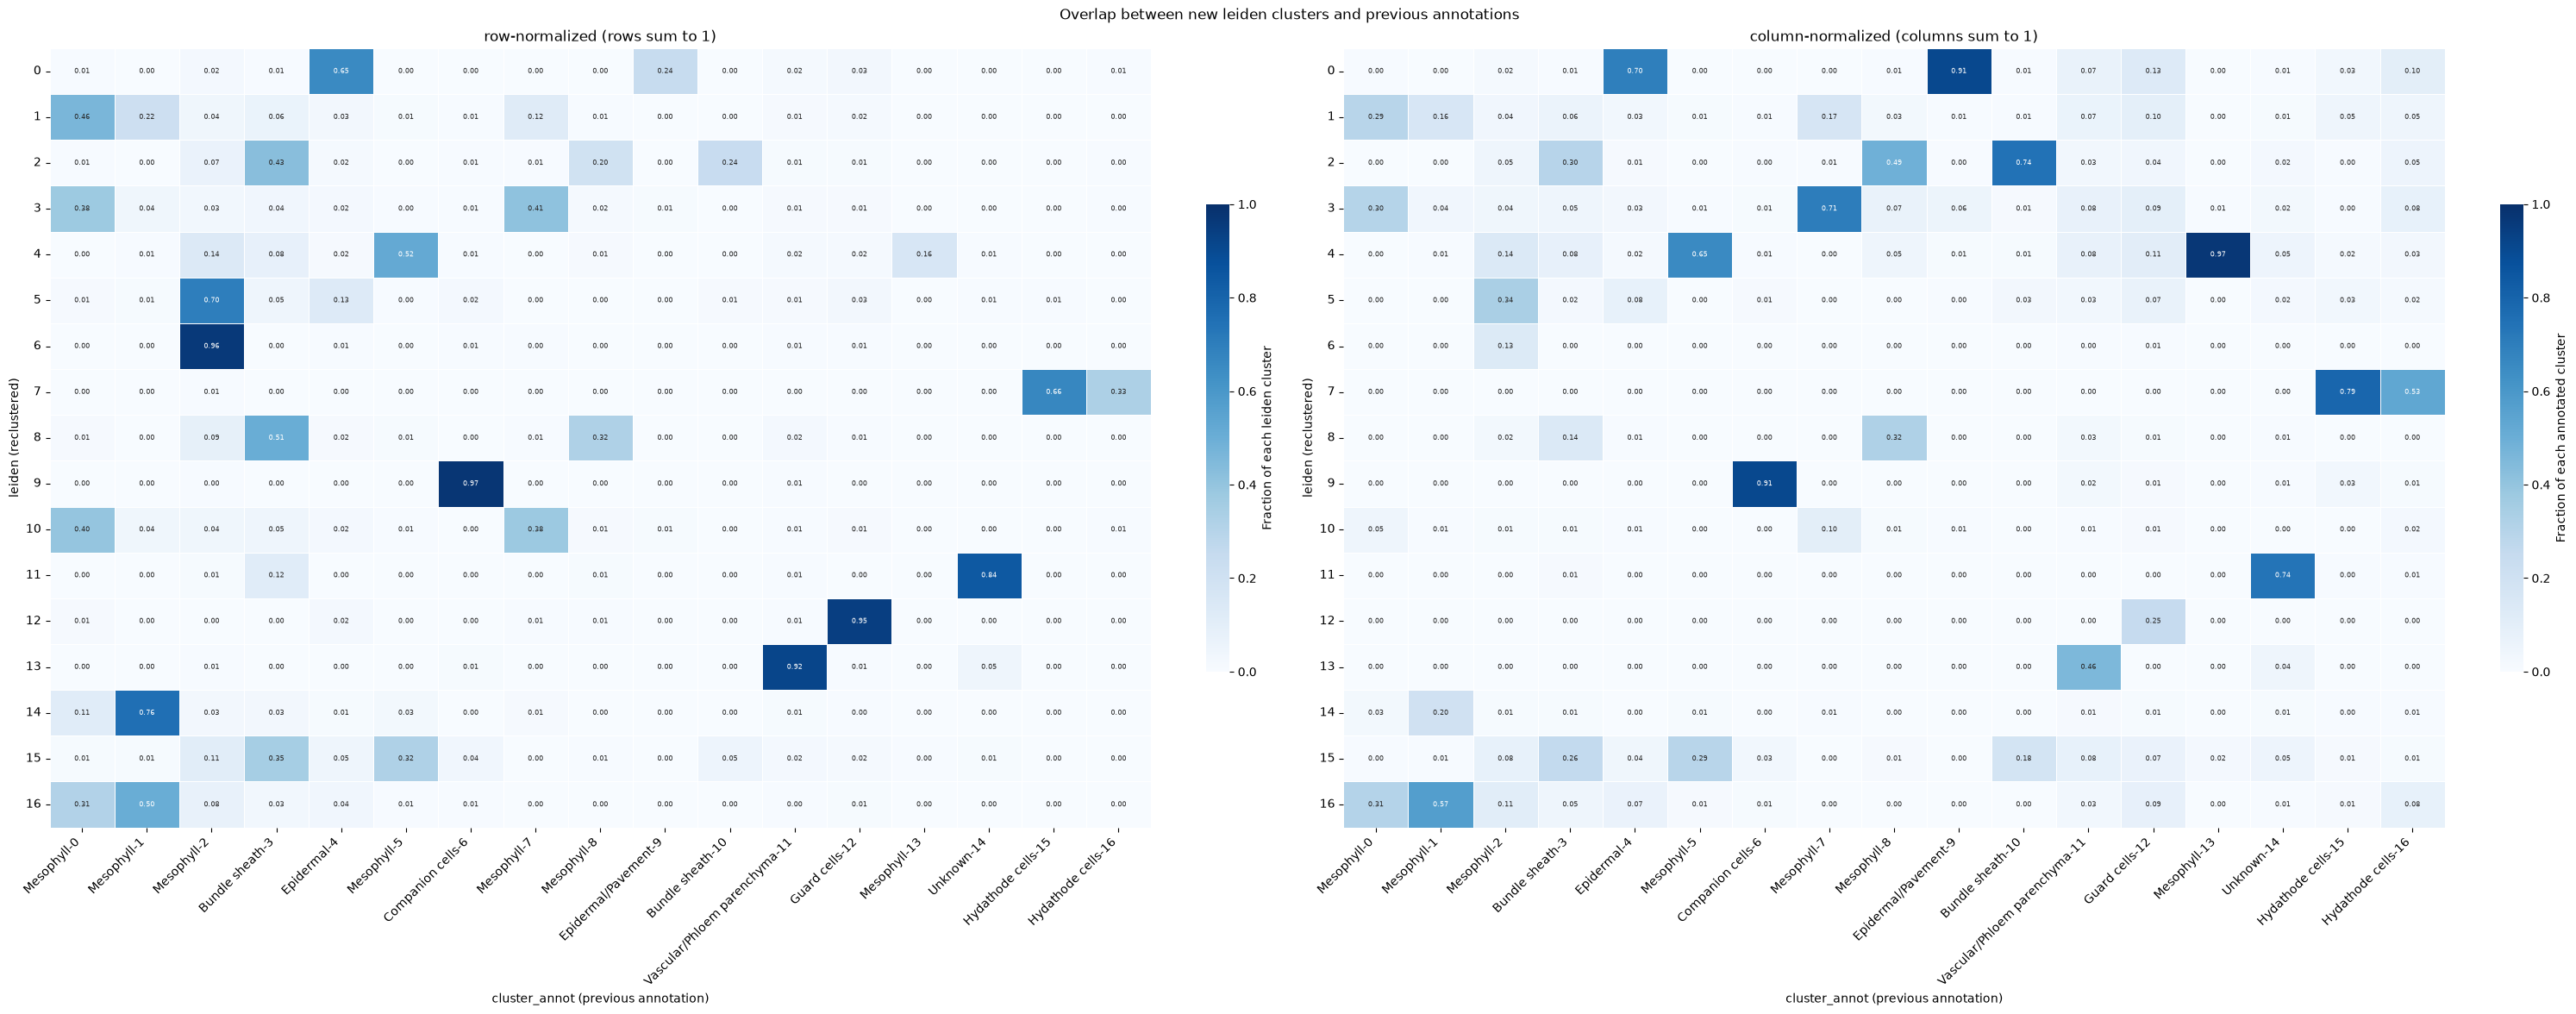

In [ ]:
# Compare the new leiden clusters to the previously annotated clusters.
# Batch keys used in the concatenation map onto the sample names of the annotated object.
batch_to_sample = {
    "control_1": "leaf_control_rep1",
    "control_1a": "leaf_control_rep1A",
    "control_2": "leaf_control_rep2",
    "control_3": "leaf_control_rep3",
    "heat_1": "leaf_Heat_rep1",
    "heat_2": "leaf_Heat_rep2",
    "heat_3": "leaf_Heat_rep3",
    "drought_1": "leaf_drought_rep1",
    "drought_2": "leaf_drought_rep2",
    "drought_3": "leaf_drought_rep3",
    "HD_1": "leaf_HD_rep1",
    "HD_2": "leaf_HD_rep2",
    "HD_3": "leaf_HD_rep3",
}

# "AAACAGCCATGTCGCG-1-control_1" -> "leaf_control_rep1_AAACAGCCATGTCGCG-1"
new_clusters = pd.Series(
    full_concatenated_adata.obs["leiden"].astype(str).values,
    index=[
        f"{batch_to_sample[batch]}_{name.rsplit('-', 1)[0]}"
        for name, batch in zip(
            full_concatenated_adata.obs_names,
            full_concatenated_adata.obs["batch"].astype(str),
        )
    ],
    name="leiden",
)
old_clusters = pd.Series(
    labeled_data.obs["cluster_annot"].astype(str).values,
    index=labeled_data.obs_names,
    name="cluster_annot",
)

shared = pd.concat([new_clusters, old_clusters], axis=1, join="inner")
print(
    f"{len(shared)} cells shared "
    f"({full_concatenated_adata.n_obs} reclustered, {labeled_data.n_obs} annotated)"
)

overlap_counts = pd.crosstab(shared["leiden"], shared["cluster_annot"])
overlap_counts = overlap_counts.loc[
    sorted(overlap_counts.index, key=int),
    sorted(overlap_counts.columns, key=lambda c: int(c.rsplit("-", 1)[1])),
]

# Normalize both ways so cluster size differences do not drive the colors
frac_of_leiden = overlap_counts.div(overlap_counts.sum(axis=1), axis=0)
frac_of_annot = overlap_counts.div(overlap_counts.sum(axis=0), axis=1)

n_rows, n_cols = overlap_counts.shape
fig, axes = plt.subplots(
    1, 2, figsize=(2 * (0.7 * n_cols + 3), 0.45 * n_rows + 4), constrained_layout=True
)
panels = [
    (
        frac_of_leiden,
        "Fraction of each leiden cluster",
        "row-normalized (rows sum to 1)",
    ),
    (
        frac_of_annot,
        "Fraction of each annotated cluster",
        "column-normalized (columns sum to 1)",
    ),
]
for ax, (matrix, cbar_label, title) in zip(axes, panels):
    sns.heatmap(
        matrix,
        ax=ax,
        cmap="Blues",
        vmin=0,
        vmax=1,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 6},
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": cbar_label, "shrink": 0.6},
    )
    ax.set_title(title)
    ax.set_xlabel("cluster_annot (previous annotation)")
    ax.set_ylabel("leiden (reclustered)")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

fig.suptitle("Overlap between new leiden clusters and previous annotations")
plt.show()

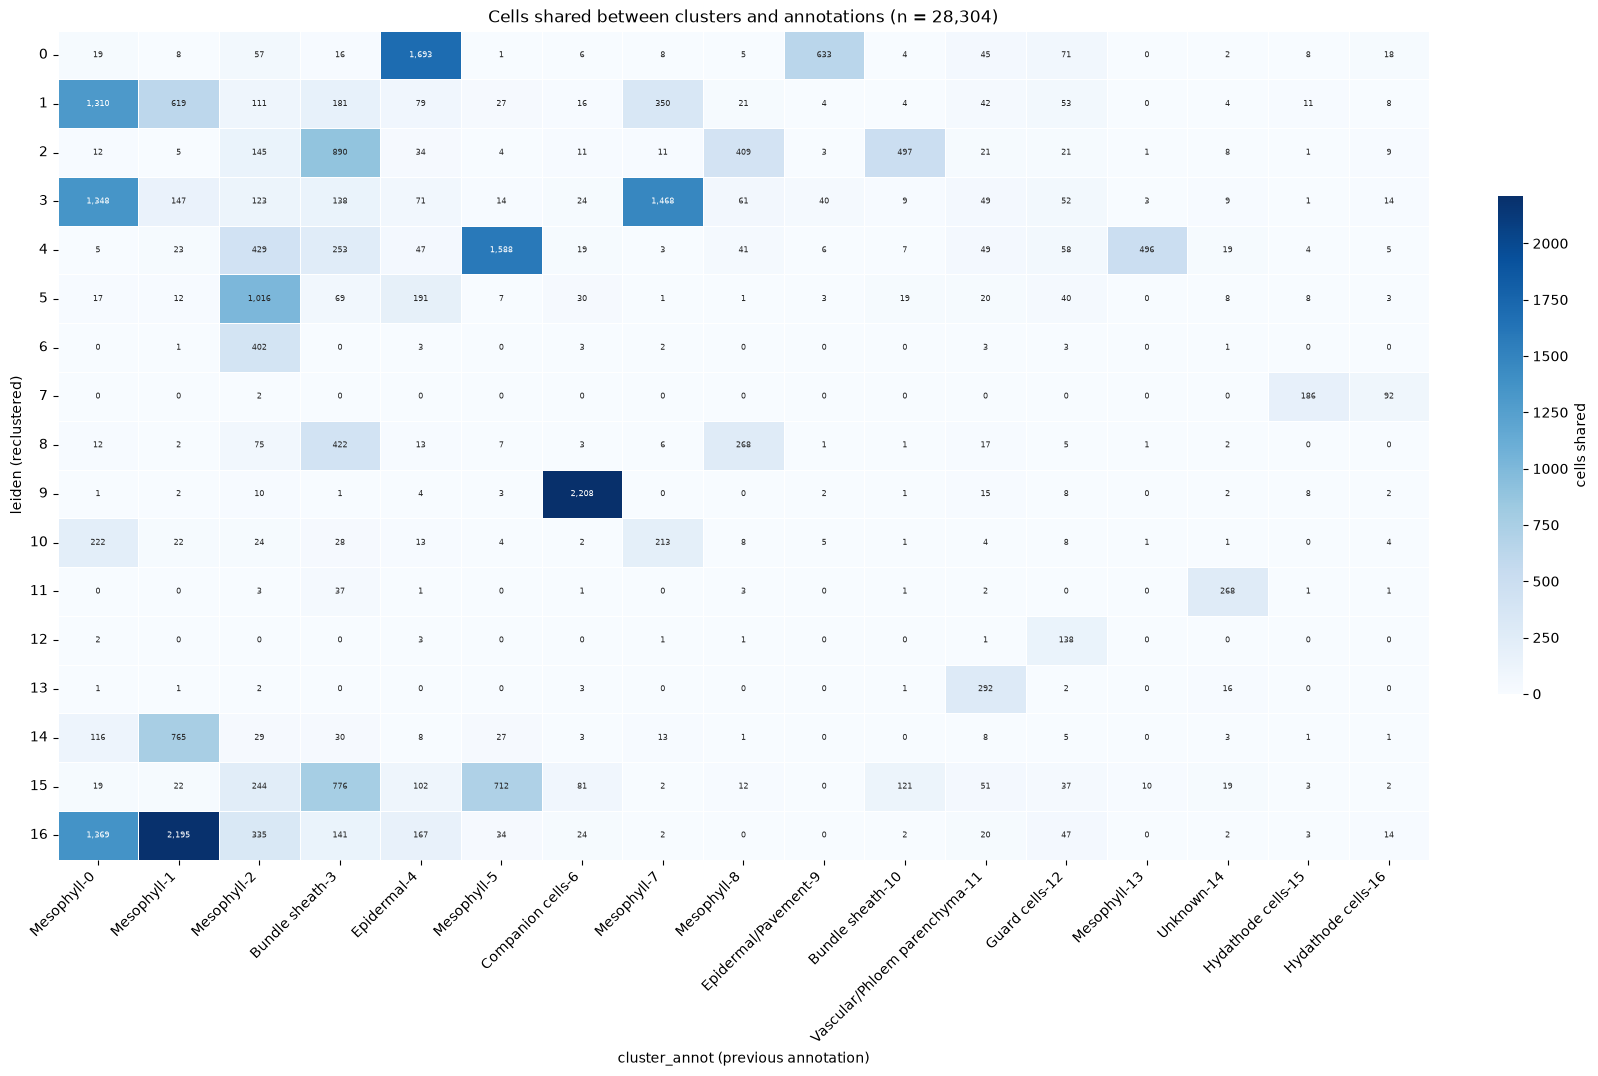

leiden
0     2594
1     2840
2     2082
3     3571
4     3052
5     1445
6      418
7      280
8      835
9     2267
10     560
11     318
12     146
13     318
14    1010
15    2213
16    4355

cluster_annot
Mesophyll-0                      4453
Mesophyll-1                      3824
Mesophyll-2                      3007
Bundle sheath-3                  2982
Epidermal-4                      2429
Mesophyll-5                      2428
Companion cells-6                2434
Mesophyll-7                      2080
Mesophyll-8                       831
Epidermal/Pavement-9              697
Bundle sheath-10                  668
Vascular/Phloem parenchyma-11     639
Guard cells-12                    548
Mesophyll-13                      512
Unknown-14                        364
Hydathode cells-15                235
Hydathode cells-16                173


In [ ]:
# Same overlap, unnormalized: total number of cells shared by each pair
fig, ax = plt.subplots(
    figsize=(0.7 * n_cols + 4, 0.45 * n_rows + 3), constrained_layout=True
)
sns.heatmap(
    overlap_counts,
    ax=ax,
    cmap="Blues",
    vmin=0,
    annot=True,
    fmt=",d",
    annot_kws={"size": 6},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "cells shared", "shrink": 0.6},
)
ax.set_title(f"Cells shared between clusters and annotations (n = {len(shared):,})")
ax.set_xlabel("cluster_annot (previous annotation)")
ax.set_ylabel("leiden (reclustered)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.show()

# Cluster sizes behind the heatmap
print(overlap_counts.sum(axis=1).rename("cells per leiden cluster").to_string())
print()
print(overlap_counts.sum(axis=0).rename("cells per annotated cluster").to_string())

In [ ]:
# Same overlap, unnormalized, but rows sorted to visually align max values along the diagonal
row_order = np.argsort(np.argmax(overlap_counts.values, axis=1))
overlap_counts_sorted = overlap_counts.iloc[row_order]

fig, ax = plt.subplots(
    figsize=(0.7 * n_cols + 4, 0.45 * n_rows + 3), constrained_layout=True
)
sns.heatmap(
    overlap_counts_sorted,
    ax=ax,
    cmap="Blues",
    vmin=0,
    annot=True,
    fmt=",d",
    annot_kws={"size": 6},
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "cells shared", "shrink": 0.6},
)
ax.set_title(
    f"Cells shared between clusters and annotations (n = {len(shared):,}) - Diagonalized"
)
ax.set_xlabel("cluster_annot (previous annotation)")
ax.set_ylabel("leiden (reclustered)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.show()

---

# Pseudobulk differential expression with PyDESeq2

Analyses **1** and **2** from `Initial_exploration/redo_de_genes.ipynb`, run on the cells
reclustered above instead of on the collaborator's `adata_rna.h5ad`. Both are built from
**raw integer counts**:

1. **Library-level pseudobulk** - one pseudosample per library (3 Control, 3 Drought, 3 Heat,
   3 HD, after pooling `control_1a` into `control_1`), design `~ replicate + treatment`. The statistically conservative reference analysis:
   its replicates are true biological replicates.
2. **Leiden micro-cluster pseudobulk** - leiden is re-run separately within each library and
   cells are pooled by micro-cluster, giving many small pseudo-replicates per treatment,
   design `~ replicate + treatment`.

Analysis 3 of that notebook (cell type as a second factor) is not ported: it needs
`celltype_call`, which is an annotation of the collaborator's object and has no counterpart
in this de-novo clustering.

> **Caveat for analysis 2.** Micro-clusters drawn from the same library are not independent
> biological replicates, so their p-values are anti-conservative compared with analysis 1.
> Treat 1 as the reference and 2 as a higher-resolution view; the concordance cell at the end
> quantifies the gap. Library cannot be added to the design as a covariate because it is
> nested inside treatment.

> **Two differences from `redo_de_genes.ipynb`, both forced by this object.** The counts have
> to be re-read from the CellRanger matrices, because `sc.pp.normalize_total` above rewrote
> `.X` in place and no `layers["counts"]` was kept. And `treatment` / `replicate` have to be
> derived from `batch`, which is the only sample-level column this object carries.

> **`control_1a` is pooled into `control_1`** throughout, via `MERGE_LIBRARIES` in the
> metadata cell. See the note there for why.

In [ ]:
from pathlib import Path

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from scipy import sparse

RESULTS_DIR = Path("de_results_harmony")  # keep the unintegrated results intact

TREATMENTS = [
    "Control",
    "Drought",
    "Heat",
    "HD",
]  # Control first -> DESeq2 reference level
CONDITIONS = ["Drought", "Heat", "HD"]  # each contrasted against Control
REPLICATES = ["rep1", "rep1A", "rep2", "rep3"]

LEIDEN_KEY = "leiden_within_library"  # micro-clusters, computed one library at a time
LEIDEN_RES = 5  # resolution for that clustering (see the note in section 2)

MIN_GENE_TOTAL = 10  # gene filter: total counts across pseudosamples
MIN_GENE_FRAC = 0.10  # gene filter: fraction of pseudosamples with a non-zero count
ALPHA, LFC_CUT = 0.05, 1.0  # thresholds used for the significance summaries
N_CPUS = 8
SAVE_RESULTS = True

CONTRASTS = {f"{c} vs Control": ["treatment", c, "Control"] for c in CONDITIONS}

### Sample-level metadata

`batch` is the only sample column on this object, and it names the 13 CellRanger runs. The
designs below need the two factors it confounds pulled apart, plus one merge.

**`control_1a` is pooled into `control_1`.** It is a second Control 10x run from the rep1
batch, and left on its own it forms a singleton `rep1A` block: a replicate level containing
one library, of one treatment. That level costs a coefficient and contributes nothing to any
treatment contrast, because there is no non-Control library in it to contrast against.
Pooling the two runs into a single Control/rep1 library leaves a balanced randomized complete
block design - **3 replicates x 4 treatments, one library each** - which is what the rest of
the notebook assumes.

`replicate` is the block term, and it is *crossed* with treatment: every block holds all four
conditions, so both effects are estimable. `libraries` is *nested* inside treatment (each
library is one condition), so it can never be a covariate.

One caveat on the pooling: the two runs differ sharply in depth before QC (median 535 vs 133
genes per cell), though the `min_genes=500` filter above brings the survivors much closer
(3,396 and 3,725 cells). Section 2 clusters within the *merged* library, so a micro-cluster
there can span both runs - harmless for the design, since both are Control/rep1, but it is a
real batch boundary being crossed.

In [ ]:
# control_1a is a second Control 10x run from the rep1 batch. Pooling it into control_1
# turns an unbalanced 13-library layout with a singleton rep1A block into a balanced
# randomized complete block design: 3 replicates x 4 treatments, one library each.
# Everything downstream keys off `libraries`, so this dict is the only place it happens.
MERGE_LIBRARIES = {"control_1a": "control_1"}

PREFIX_TO_TREATMENT = {
    "control": "Control",
    "heat": "Heat",
    "drought": "Drought",
    "HD": "HD",
}
SUFFIX_TO_REPLICATE = {"1": "rep1", "1a": "rep1A", "2": "rep2", "3": "rep3"}

# `batch` still names the 13 CellRanger runs; `libraries` is what the DE groups by.
_merged = full_concatenated_adata.obs["batch"].astype(str).replace(MERGE_LIBRARIES)
_split = _merged.str.rsplit("_", n=1)
_replicate = _split.str[1].map(SUFFIX_TO_REPLICATE)

full_concatenated_adata.obs["treatment"] = pd.Categorical(
    _split.str[0].map(PREFIX_TO_TREATMENT), categories=TREATMENTS
)
# drop replicate levels the merge emptied out, so no unused factor level reaches DESeq2
full_concatenated_adata.obs["replicate"] = pd.Categorical(
    _replicate, categories=[r for r in REPLICATES if r in set(_replicate)]
)
full_concatenated_adata.obs["libraries"] = pd.Categorical(_merged)

print(
    f"{full_concatenated_adata.obs['libraries'].nunique()} libraries after merging "
    f"{len(MERGE_LIBRARIES)}"
)
pd.crosstab(
    full_concatenated_adata.obs["treatment"], full_concatenated_adata.obs["replicate"]
)

### Raw counts

DESeq2 needs raw integer counts, and this object no longer has any: `sc.pp.normalize_total`
followed by `sc.pp.log1p` rewrote `.X` in place, and no counts layer was set aside first.

They are recoverable exactly, because nothing upstream of the normalisation was stochastic.
`load_raw_counts()` re-reads the same 13 CellRanger directories with the same
`var_names="gene_symbols"`, concatenates them in the same order, and then subsets to whatever
cells and genes survived `filter_cells` / `filter_genes` above - so the result is the matrix
that was in `.X` immediately before normalisation.

In [ ]:
# same order as the concatenation above, so the "-<batch>" obs_name suffixes line up
RAW_SOURCES = [
    ("control_1", control_1_file_loc),
    ("control_2", control_2_file_loc),
    ("control_3", control_3_file_loc),
    ("control_1a", control_1a_file_loc),
    ("heat_1", heat_1_file_loc),
    ("heat_2", heat_2_file_loc),
    ("heat_3", heat_3_file_loc),
    ("drought_1", drought_1_file_loc),
    ("drought_2", drought_2_file_loc),
    ("drought_3", drought_3_file_loc),
    ("HD_1", HD_1_file_loc),
    ("HD_2", HD_2_file_loc),
    ("HD_3", HD_3_file_loc),
]


def load_raw_counts(adata, sources=RAW_SOURCES):
    """Re-read the CellRanger matrices and align them to `adata`'s cells and genes."""
    parts = [sc.read_10x_mtx(loc, var_names="gene_symbols") for _, loc in sources]
    raw = ad.concat(
        parts,
        join="outer",
        label="batch",
        keys=[key for key, _ in sources],
        index_unique="-",
    )
    del parts
    raw = raw[adata.obs_names, adata.var_names].copy()

    data = raw.X.data if sparse.issparse(raw.X) else np.asarray(raw.X).ravel()
    if not np.allclose(data, np.rint(data)):
        raise ValueError("re-read matrix does not hold integer counts")

    raw.obs = adata.obs.copy()  # treatment / replicate / libraries / leiden
    return raw


counts_adata = load_raw_counts(full_concatenated_adata)
print(counts_adata)
print("\ncells per treatment / library:")
print(counts_adata.obs.groupby(["treatment", "libraries"], observed=True).size())

In [ ]:
def pseudobulk(adata, group_keys, meta_keys=()):
    """Sum raw counts within each group of cells.

    Returns (counts, metadata): a pseudosamples x genes integer count matrix, and a matching
    metadata frame holding the grouping columns, the majority value of each `meta_keys` column,
    and the number of cells per pseudosample.
    """
    group_keys = list(group_keys)
    labels = adata.obs[group_keys].astype(str).agg(" | ".join, axis=1).to_numpy()
    cats = pd.Categorical(labels)
    n_cells = np.bincount(cats.codes, minlength=len(cats.categories))

    indicator = sparse.csr_matrix(
        (np.ones(adata.n_obs), (cats.codes, np.arange(adata.n_obs))),
        shape=(len(cats.categories), adata.n_obs),
    )
    summed = indicator @ adata.X
    summed = (
        np.asarray(summed.todense()) if sparse.issparse(summed) else np.asarray(summed)
    )
    counts = pd.DataFrame(
        np.rint(summed).astype(np.int64),
        index=list(cats.categories),
        columns=adata.var_names,
    )

    meta_cols = group_keys + [k for k in meta_keys if k not in group_keys]
    frame = adata.obs[meta_cols].astype(str).copy()
    frame["_group"] = labels
    meta = frame.groupby("_group", observed=True)[meta_cols].agg(
        lambda s: s.value_counts().index[0]
    )
    meta["n_cells"] = pd.Series(n_cells, index=list(cats.categories))
    if "treatment" in meta:
        meta["treatment"] = pd.Categorical(meta["treatment"], categories=TREATMENTS)
    return counts, meta.loc[counts.index]


def filter_genes(counts, min_total=MIN_GENE_TOTAL, min_frac_samples=MIN_GENE_FRAC):
    """Drop genes with too little signal to be testable (also keeps PyDESeq2 fast)."""
    min_samples = max(2, int(np.ceil(min_frac_samples * counts.shape[0])))
    keep = ((counts > 0).sum(axis=0) >= min_samples) & (counts.sum(axis=0) >= min_total)
    print(f"genes kept: {int(keep.sum())} / {counts.shape[1]}")
    return counts.loc[:, keep.to_numpy()]

In [ ]:
def run_deseq(counts, meta, design, contrasts=None, n_cpus=N_CPUS, **kwargs):
    """Fit one DESeq2 model and run a Wald test for each contrast."""
    contrasts = CONTRASTS if contrasts is None else contrasts
    dds = DeseqDataSet(
        counts=counts, metadata=meta, design=design, n_cpus=n_cpus, quiet=True, **kwargs
    )
    dds.deseq2()
    results = {}
    for name, contrast in contrasts.items():
        stat = DeseqStats(dds, contrast=contrast, n_cpus=n_cpus, quiet=True)
        stat.summary()
        results[name] = stat.results_df.sort_values("padj")
    return dds, results


def sig_genes(res, alpha=ALPHA, lfc_cut=LFC_CUT):
    return res.index[(res["padj"] < alpha) & (res["log2FoldChange"].abs() >= lfc_cut)]


def de_summary(results, alpha=ALPHA, lfc_cut=LFC_CUT):
    rows = []
    for name, res in results.items():
        sig = res.loc[sig_genes(res, alpha, lfc_cut)]
        rows.append(
            {
                "comparison": name,
                "genes_tested": int(res["padj"].notna().sum()),
                f"padj<{alpha}": int((res["padj"] < alpha).sum()),
                f"padj<{alpha} & |LFC|>={lfc_cut}": len(sig),
                "up": int((sig["log2FoldChange"] > 0).sum()),
                "down": int((sig["log2FoldChange"] < 0).sum()),
            }
        )
    return pd.DataFrame(rows).set_index("comparison")


def top_genes(results, n=10):
    """Top `n` genes by adjusted p-value for each comparison, side by side."""
    frames = []
    for name, res in results.items():
        top = res.dropna(subset=["padj"]).head(n)
        frames.append(
            pd.DataFrame(
                {
                    (name, "gene"): top.index,
                    (name, "log2FC"): top["log2FoldChange"].round(2).to_numpy(),
                    (name, "padj"): top["padj"].to_numpy(),
                }
            ).reset_index(drop=True)
        )
    out = pd.concat(frames, axis=1)
    out.columns = pd.MultiIndex.from_tuples(out.columns)
    return out


def save_results(results, prefix):
    if not SAVE_RESULTS:
        return
    RESULTS_DIR.mkdir(exist_ok=True)
    for name, res in results.items():
        res.to_csv(RESULTS_DIR / f"{prefix}__{name.replace(' ', '_')}.csv")
    print(f"saved {len(results)} tables to {RESULTS_DIR.resolve()}")

## 1. Library-level pseudobulk (`~ replicate + treatment`)

One pseudosample per library, after the merge: 3 Control, 3 Drought, 3 Heat, 3 HD. With only
a handful of replicates, genes are required to be detected in at least half of the libraries.

In [ ]:
lib_counts, lib_meta = pseudobulk(
    counts_adata, group_keys=["libraries"], meta_keys=["treatment", "replicate"]
)
print(lib_counts.shape)
lib_meta[["treatment", "replicate", "n_cells"]]

In [ ]:
lib_counts_f = filter_genes(lib_counts, min_frac_samples=0.5)
lib_dds, lib_results = run_deseq(
    lib_counts_f, lib_meta, design="~replicate + treatment"
)
de_summary(lib_results)

In [ ]:
save_results(lib_results, "library_pseudobulk")
top_genes(lib_results)

## 2. Leiden micro-cluster pseudobulk (`~ replicate + treatment`)

Leiden is re-run **one library at a time**. A clustering computed over all cells at once lets a
micro-cluster straddle libraries and conditions, and splitting such a cluster by treatment
afterwards only leaves unbalanced fragments of it. Because libraries are separate batches,
clustering inside each one makes every group pure for library *and* treatment by construction.

Resolution is relative to the size of the graph being clustered, so a value tuned on all
30,000 cells is far too high for a single 750-5,300 cell library. `LEIDEN_RES = 5` is the
value `redo_de_genes.ipynb` settled on for an object of almost exactly this size (30,139 cells
here against 30,467 there, same 13 libraries), aiming for group sizes in the 10-400 range.
On this object it gives **626 micro-clusters** (144-178 per treatment), median 34 cells,
range 2-334. Resolution 2 is the more conservative alternative; the printout below reports
what you actually got, so retune from that rather than from this paragraph.

In [ ]:
# re-cluster inside each library, so no micro-cluster can mix batches or conditions
micro_labels = pd.Series(index=counts_adata.obs_names, dtype=object)

for library in counts_adata.obs["libraries"].unique():
    sub = full_concatenated_adata[
        full_concatenated_adata.obs["libraries"] == library
    ].copy()
    sub.uns.pop("neighbors", None)  # the stored graph belongs to the full object
    sc.pp.neighbors(sub, use_rep=EMBEDDING)
    sc.tl.leiden(
        sub,
        resolution=LEIDEN_RES,
        key_added="_leiden",
        flavor="igraph",
        n_iterations=2,
    )
    micro_labels[sub.obs_names] = str(library) + "_" + sub.obs["_leiden"].astype(str)

    sizes = sub.obs["_leiden"].value_counts()
    print(
        f"{str(library):>20}: {sub.n_obs:>5} cells -> {sizes.size:>3} clusters, "
        f"median {sizes.median():.0f}, range {sizes.min()}-{sizes.max()}"
    )

counts_adata.obs[LEIDEN_KEY] = pd.Categorical(micro_labels)
full_concatenated_adata.obs[LEIDEN_KEY] = pd.Categorical(
    micro_labels.reindex(full_concatenated_adata.obs_names)
)
print(
    f"\n{micro_labels.nunique()} micro-clusters, {micro_labels.isna().sum()} cells unassigned"
)

In [ ]:
micro_counts, micro_meta = pseudobulk(
    counts_adata,
    group_keys=["treatment", LEIDEN_KEY],
    meta_keys=["libraries", "replicate"],
)
print(f"{micro_counts.shape[0]} pseudosamples x {micro_counts.shape[1]} genes")
print("\npseudosamples per treatment:")
print(micro_meta["treatment"].value_counts().reindex(TREATMENTS))
print("\ncells per pseudosample:")
print(micro_meta["n_cells"].describe().round(1))
micro_meta.head()

In [ ]:
# hundreds of pseudosamples x ~20k genes -- this fit is the slowest step (minutes)
micro_counts_f = filter_genes(micro_counts)
micro_dds, micro_results = run_deseq(
    micro_counts_f, micro_meta, design="~replicate + treatment"
)
de_summary(micro_results)

In [ ]:
save_results(micro_results, "leiden_micro_pseudobulk")
top_genes(micro_results)

### Concordance between the two analyses

How far the anti-conservative micro-cluster calls track the conservative library-level ones.
A high recovery percentage with a strong LFC rank correlation means analysis 2 is adding
resolution rather than noise.

In [ ]:
rows = []
for name in CONTRASTS:
    lib_res, mic_res = lib_results[name], micro_results[name]
    lib_sig, mic_sig = set(sig_genes(lib_res)), set(sig_genes(mic_res))
    shared = lib_res.index.intersection(mic_res.index)
    rows.append(
        {
            "comparison": name,
            "library sig": len(lib_sig),
            "micro sig": len(mic_sig),
            "shared": len(lib_sig & mic_sig),
            "% of library sig recovered": round(
                100 * len(lib_sig & mic_sig) / max(len(lib_sig), 1), 1
            ),
            "LFC spearman (shared genes)": round(
                lib_res.loc[shared, "log2FoldChange"].corr(
                    mic_res.loc[shared, "log2FoldChange"], method="spearman"
                ),
                3,
            ),
        }
    )
pd.DataFrame(rows).set_index("comparison")

## 3. Per-cluster library pseudobulk (`~ replicate + treatment`)

Analysis 1 again - one pseudosample per library, DESeq2, blocked on replicate - but run
**once inside each de-novo leiden cluster** from the clustering above. Cells are summed per
(cluster, library), so a pseudosample is one library's contribution to one cluster, and the
treatment effect is estimated within a cluster instead of across the whole leaf.

Two rules decide what actually gets tested. Both are reported rather than applied silently:

* a pseudosample with fewer than `MIN_CELLS_PER_PSEUDOSAMPLE` cells is discarded;
* a contrast needs at least `MIN_LIBS_PER_TREATMENT` surviving libraries on **both** sides.
  A cluster holding no Control libraries has no Control coefficient, so its contrasts do not
  exist - that is structural, not a filter.

That second rule bites hard here, because this clustering is strongly batch-confounded: of
the 18 clusters, 17 is 97% `HD_1`, 12 is 92% `heat_2`, 9 is 89% `drought_2`, and clusters
15-17 contain no Control cells at all. Those clusters are real (they are what the stress
libraries look like), but they cannot support a within-cluster contrast against Control.

The blocked design is used wherever it is estimable with at least 2 residual degrees of
freedom; otherwise the cluster falls back to `~treatment`, and which one was used is recorded
per cluster in the summary table.

The gene filter is `min_frac_samples=0.5`, matching analysis 1 - this is that analysis, so it
gets that filter. On ~10 shallow pseudosamples the looser 0.10 default admits ~30k barely
observed genes and spends the multiple-testing budget on them.

**Read the outcome as a power result.** Splitting 30,139 cells across 18 clusters leaves each
pseudosample roughly ten times shallower than in analysis 1 (a few hundred cells instead of a
few thousand), and almost every cluster then calls nothing. The one cluster represented in
all 12 libraries, cluster 8, carries nearly all of the signal there is. That is the same failure
mode flagged for the collaborator's `Mesophyll-7`: a per-cell-type contrast that quietly
returns nothing because the cell type is not present across enough libraries, rather than
because the biology is absent.

In [ ]:
CLUSTER_KEY = "leiden"  # the de-novo clusters from sc.tl.leiden above
MIN_CELLS_PER_PSEUDOSAMPLE = (
    10  # a cluster x library group smaller than this is discarded
)
MIN_LIBS_PER_TREATMENT = (
    2  # both sides of a contrast need this many surviving libraries
)


def choose_design(meta):
    """Blocked design where it is estimable with df to spare, else `~treatment`, else None."""
    for design, cols in (
        ("~replicate + treatment", ["replicate", "treatment"]),
        ("~treatment", ["treatment"]),
    ):
        X = pd.get_dummies(meta[cols].astype(str), drop_first=True).astype(float)
        X.insert(0, "intercept", 1.0)
        full_rank = np.linalg.matrix_rank(X.to_numpy()) == X.shape[1]
        if full_rank and len(X) - X.shape[1] >= 2:
            return design
    return None

In [ ]:
clus_counts, clus_meta = pseudobulk(
    counts_adata,
    group_keys=[CLUSTER_KEY, "libraries"],
    meta_keys=["treatment", "replicate"],
)
print(f"{clus_counts.shape[0]} cluster x library pseudosamples")

clus_meta = clus_meta[clus_meta["n_cells"] >= MIN_CELLS_PER_PSEUDOSAMPLE]
clus_counts = clus_counts.loc[clus_meta.index]
print(
    f"{clus_counts.shape[0]} left after discarding groups under "
    f"{MIN_CELLS_PER_PSEUDOSAMPLE} cells"
)

pd.crosstab(clus_meta[CLUSTER_KEY], clus_meta["treatment"])

In [ ]:
cluster_results, cluster_skipped, rows = {}, {}, []

for cl in sorted(clus_meta[CLUSTER_KEY].unique(), key=int):
    meta = clus_meta[clus_meta[CLUSTER_KEY] == cl].copy()
    n_by_treatment = meta["treatment"].value_counts()
    present = [
        t for t in TREATMENTS if n_by_treatment.get(t, 0) >= MIN_LIBS_PER_TREATMENT
    ]
    if "Control" not in present or len(present) < 2:
        cluster_skipped[cl] = (
            f"treatments with >={MIN_LIBS_PER_TREATMENT} libraries: "
            + (", ".join(present) if present else "none")
        )
        print(f"cluster {cl:>2}: skipped -- {cluster_skipped[cl]}")
        continue

    meta = meta[meta["treatment"].isin(present)].copy()
    meta["treatment"] = pd.Categorical(
        meta["treatment"].astype(str),
        categories=[t for t in TREATMENTS if t in present],
    )
    meta["replicate"] = meta["replicate"].astype(str)

    design = choose_design(meta)
    if design is None:
        cluster_skipped[cl] = "no estimable design"
        print(f"cluster {cl:>2}: skipped -- no estimable design")
        continue

    here = {name: c for name, c in CONTRASTS.items() if c[1] in present}
    counts_here = filter_genes(clus_counts.loc[meta.index], min_frac_samples=0.5)
    _, res = run_deseq(counts_here, meta, design=design, contrasts=here)
    cluster_results[cl] = res

    rows.append(
        {
            "cluster": cl,
            "pseudosamples": len(meta),
            "cells": int(meta["n_cells"].sum()),
            "design": design,
            "genes_tested": counts_here.shape[1],
            **{name: len(sig_genes(r)) for name, r in res.items()},
        }
    )
    print(
        f"cluster {cl:>2}: {len(meta):>2} pseudosamples, {design}, "
        + ", ".join(f"{name}={len(sig_genes(r))}" for name, r in res.items())
    )

cluster_summary = pd.DataFrame(rows).set_index("cluster")
cluster_summary

In [ ]:
RESULTS_DIR.mkdir(exist_ok=True)
cluster_summary.to_csv(RESULTS_DIR / "per_cluster_de_summary.csv")
print(f"saved the per-cluster summary to {RESULTS_DIR.resolve()}")

# The full DESeq2 table for every (cluster, contrast) stays in `cluster_results` -- writing
# all ~35 of them out is ~150 MB of mostly non-significant rows, so only the summary and the
# gene lists below are persisted. To write one out by hand:
#     cluster_results["8"]["HD vs Control"].to_csv(RESULTS_DIR / "cluster8_HD.csv")

### Union and intersection across clusters

Two gene lists per contrast, both taken over the clusters where that contrast was actually
testable (listed in `tested_clusters` below - taking them over all 18 would make the
intersection empty by construction, since several clusters have no Control cells):

* **`union_de[contrast]`** - DE in *at least one* cluster.
* **`intersection_de[contrast]`** - DE in *every* tested cluster, i.e. the shared core
  response that does not depend on which cluster you look in.

`cluster_recurrence[contrast]` is the table both are cut from: one row per gene in the union,
with how many clusters called it and which ones. The intersection is the rows where
`n_clusters_DE == n_clusters_tested`, so any intermediate threshold ("DE in at least half the
clusters") can be read straight off it without refitting anything.

"DE" throughout is the same rule as the rest of the notebook: `padj < ALPHA` and
`|log2FoldChange| >= LFC_CUT`.

In [ ]:
union_de, intersection_de, cluster_recurrence, tested_clusters = {}, {}, {}, {}

for name in CONTRASTS:
    tested = [cl for cl, res in cluster_results.items() if name in res]
    if not tested:
        print(f"{name}: not testable in any cluster")
        continue
    per_cluster = {cl: set(sig_genes(cluster_results[cl][name])) for cl in tested}

    union = sorted(set().union(*per_cluster.values()))
    intersection = sorted(set.intersection(*per_cluster.values()))
    tested_clusters[name] = tested
    union_de[name], intersection_de[name] = union, intersection

    cluster_recurrence[name] = pd.DataFrame(
        {
            "gene": union,
            "n_clusters_DE": [sum(g in s for s in per_cluster.values()) for g in union],
            "clusters_DE": [
                ",".join(str(cl) for cl in tested if g in per_cluster[cl])
                for g in union
            ],
            "n_clusters_tested": len(tested),
        }
    ).sort_values(["n_clusters_DE", "gene"], ascending=[False, True], ignore_index=True)

    print(
        f"{name}: testable in {len(tested)} clusters {tested} -> "
        f"union {len(union)} genes, intersection {len(intersection)} genes"
    )

pd.DataFrame(
    {
        "clusters tested": {k: len(v) for k, v in tested_clusters.items()},
        "union": {k: len(v) for k, v in union_de.items()},
        "intersection": {k: len(v) for k, v in intersection_de.items()},
    }
)

In [ ]:
for name in union_de:
    tag = name.replace(" ", "_")
    cluster_recurrence[name].to_csv(
        RESULTS_DIR / f"per_cluster_union__{tag}.csv", index=False
    )
    pd.DataFrame({"gene": intersection_de[name]}).to_csv(
        RESULTS_DIR / f"per_cluster_intersection__{tag}.csv", index=False
    )
print(f"saved union and intersection lists to {RESULTS_DIR.resolve()}")

# the most recurrent genes per contrast -- the top of each union list
for name in union_de:
    print(f"\n{name} (tested in {len(tested_clusters[name])} clusters):")
    print(cluster_recurrence[name].head(15).to_string(index=False))

### What came out

| contrast | clusters tested | union | intersection |
|---|---|---|---|
| Heat vs Control | 14 | 20 | 0 |
| Drought vs Control | 10 | 1 | 0 |
| HD vs Control | 7 | 349 | 0 |

Against analysis 1 on the same libraries (61 / 83 / 4,141), per-cluster testing recovers
almost nothing, and **every intersection is empty**.

The empty intersections are not a knife-edge result to be recovered by nudging a threshold.
An intersection requires a gene to be called in *every* tested cluster, and most clusters call
zero genes for any contrast - so no gene can qualify. 346 of the 349 HD genes come from
cluster 8 alone, the only cluster holding all 12 libraries above the 10-cell floor; the Heat
list is likewise 11 genes from cluster 8 and 9 from cluster 3.

So the honest reading is that this dataset does not support per-cluster differential
expression at library-level resolution: 12 libraries split 18 ways is too little. If a
shared-core gene list is the goal, the options in rough order of how much they cost:

1. Use `cluster_recurrence[contrast]` with a relaxed threshold - "DE in >= 2 clusters"
   instead of all of them. Free; the table is already built.
2. Cluster more coarsely (a lower `sc.tl.leiden` resolution) so each cluster holds more cells
   from more libraries. Cluster 8 shows this is what decides the answer.
3. Drop the block term to `~treatment`, buying back 2 degrees of freedom per cluster at the
   cost of leaving replicate batch in the residual - `redo_de_genes.ipynb` showed that batch
   is the dominant axis of variation, so this trades one bias for another.
4. Pool cells across libraries within a cluster (micro-cluster style, analysis 2). Much more
   power, but the p-values stop being replicate-level and become anti-conservative.